In [1]:
import pandas as pd


In [2]:
# 读取 CSV 文件
df = pd.read_csv("/home/luojiawei/inspire_benchmark_data/operation_.csv")


In [3]:
with pd.option_context('display.max_columns', None):  # 设置显示所有列
    print(df.head(2))

       op_id  subject_id    hadm_id  case_id  opdate  age  sex  weight  \
0  400000455   179458020  222462696      NaN    1440   60    0      57   
1  400000790   119508072  241502974      NaN    1440   30    1      60   

   height   race  asa  emop department   antype icd10_pcs  orin_time  \
0     160  Asian    1     0         GS  General     0HBT0       1900   
1     168  Asian    1     0         UR  General     0VBG0       2110   

   orout_time  opstart_time  opend_time  admission_time  discharge_time  \
0        2005          1940        2000               0            4315   
1        2235          2125        2235               0            4315   

   anstart_time  anend_time  cpbon_time  cpboff_time  icuin_time  icuout_time  \
0        1920.0      2005.0         NaN          NaN         NaN          NaN   
1        2110.0      2225.0         NaN          NaN         NaN          NaN   

   inhosp_death_time        bmi   los  op_duration  or_duration  an_duration  \
0         

<Figure size 4500x1200 with 0 Axes>

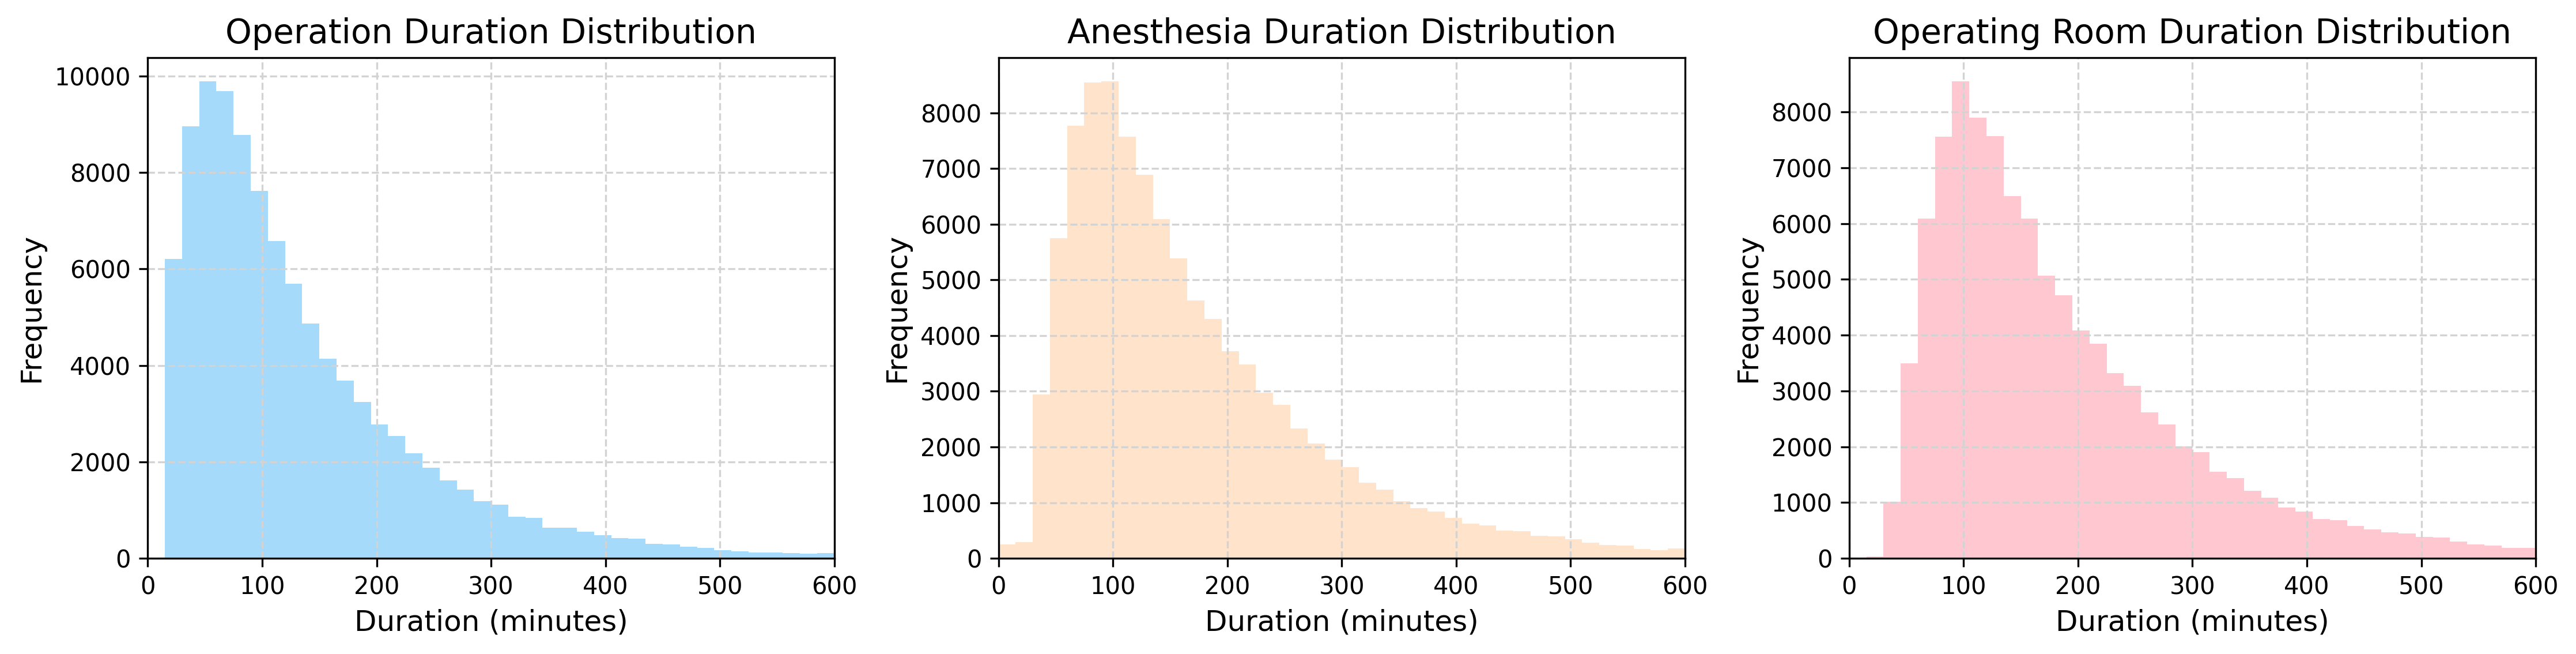

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set macaroon color palette
macaroon_colors = ['#FFB6C1', '#87CEFA', '#FFDAB9', '#98FB98', '#E0FFFF', '#FFA07A']

# First group of plots: Duration related to surgery (in minutes)
plt.figure(figsize=(15, 4), dpi=300)  # 修改为1*3的布局，设置dpi大于300
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4), dpi=300)  # Changed to 3 subplots，设置dpi大于300
fig1.subplots_adjust(hspace=0.4)

# Find the maximum value of these three metrics for a unified x-axis range
max_duration = max(
    df['or_duration'].max(),
    df['op_duration'].max(), 
    df['an_duration'].max()
)
# Add some margin and round up to the nearest 100
max_xlim = min(int(np.ceil(max_duration * 1.1 / 100) * 100), 600)
# Define bins for histogram, increasing the number of bins
bins = np.arange(0, max_xlim + 15, 15)  # Change to intervals of 15 minutes

# 1. op_duration (Operation Duration) distribution plot
sns.histplot(df['op_duration'], ax=axes1[0], color=macaroon_colors[1], bins=bins, edgecolor=None)
axes1[0].set_title('Operation Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[0].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[0].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[0].set_xlim(0, max_xlim)
axes1[0].grid(True, linestyle='--', color='lightgrey')  # 添加浅灰色网格线

# 2. an_duration (Anesthesia Duration) distribution plot
sns.histplot(df['an_duration'], ax=axes1[1], color=macaroon_colors[2], bins=bins, edgecolor=None)
axes1[1].set_title('Anesthesia Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[1].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[1].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[1].set_xlim(0, max_xlim)
axes1[1].grid(True, linestyle='--', color='lightgrey')  # 添加浅灰色网格线

# 3. or_duration (Operating Room Duration) distribution plot
sns.histplot(df['or_duration'], ax=axes1[2], color=macaroon_colors[0], bins=bins, edgecolor=None)
axes1[2].set_title('Operating Room Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[2].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[2].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[2].set_xlim(0, max_xlim)
axes1[2].grid(True, linestyle='--', color='lightgrey')  # 添加浅灰色网格线

# Add overall title
# plt.suptitle('Distribution of Surgery Related Durations (in minutes)', fontsize=16, y=0.95, fontname='DejaVu Sans')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


<Figure size 4500x5520 with 0 Axes>

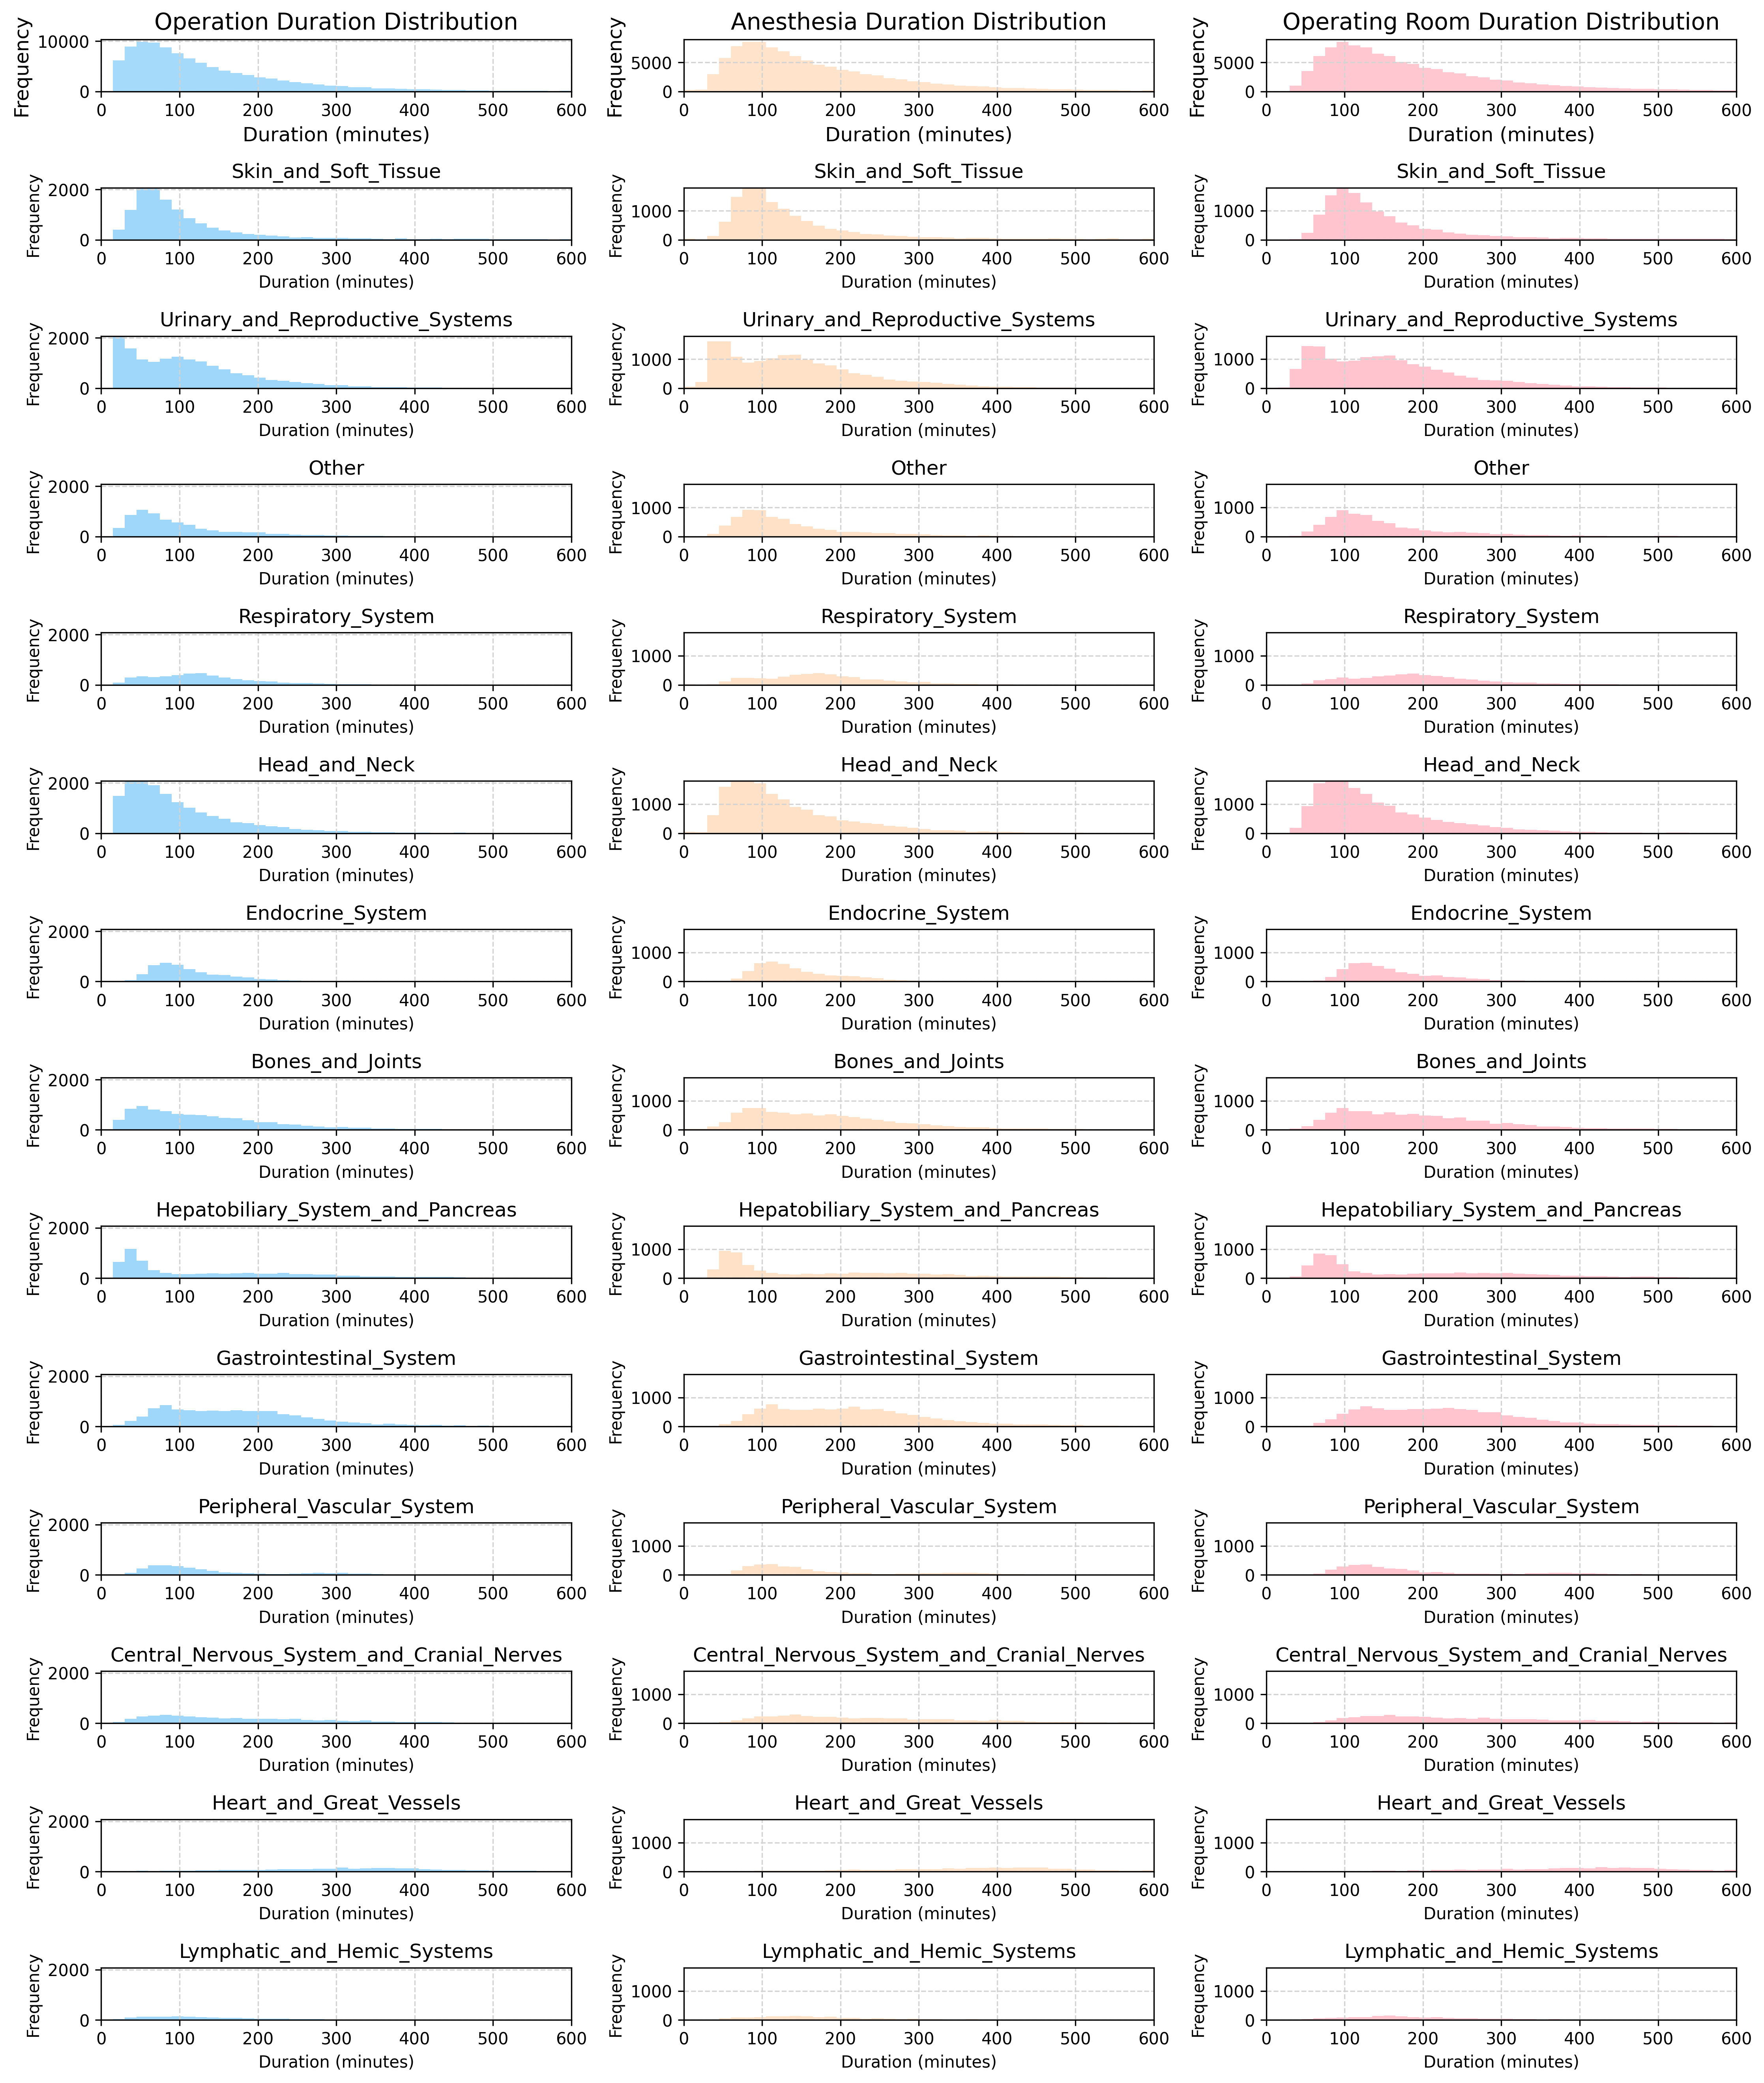

In [21]:
# 首先获取不同的手术站点
surgery_sites = df['surgery_site'].unique()
num_sites = len(surgery_sites)

# 计算新的图布局 - 每列一个指标，每行一种手术站点（第一行是总体分布）
fig_height = 8 + (4/5) * num_sites  # 增加总图高度
plt.figure(figsize=(15, fig_height), dpi=300)
fig1, axes1 = plt.subplots(1 + num_sites, 3, figsize=(15, fig_height), dpi=300)
fig1.subplots_adjust(hspace=0.5, wspace=0.3)

# 找到三个指标的最大值用于统一x轴范围
max_duration = max(
    df['or_duration'].max(),
    df['op_duration'].max(), 
    df['an_duration'].max()
)
# 添加边距并四舍五入到最接近的100
max_xlim = min(int(np.ceil(max_duration * 1.1 / 100) * 100), 600)
# 为直方图定义区间
bins = np.arange(0, max_xlim + 15, 15)

# 绘制总体分布图（第一行）
# 1. op_duration (Operation Duration) 分布图
sns.histplot(df['op_duration'], ax=axes1[0, 0], color=macaroon_colors[1], bins=bins, edgecolor=None)
axes1[0, 0].set_title('Operation Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[0, 0].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[0, 0].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[0, 0].set_xlim(0, max_xlim)
axes1[0, 0].grid(True, linestyle='--', color='lightgrey')

# 2. an_duration (Anesthesia Duration) 分布图
sns.histplot(df['an_duration'], ax=axes1[0, 1], color=macaroon_colors[2], bins=bins, edgecolor=None)
axes1[0, 1].set_title('Anesthesia Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[0, 1].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[0, 1].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[0, 1].set_xlim(0, max_xlim)
axes1[0, 1].grid(True, linestyle='--', color='lightgrey')

# 3. or_duration (Operating Room Duration) 分布图
sns.histplot(df['or_duration'], ax=axes1[0, 2], color=macaroon_colors[0], bins=bins, edgecolor=None)
axes1[0, 2].set_title('Operating Room Duration Distribution', fontsize=14, fontname='DejaVu Sans')
axes1[0, 2].set_xlabel('Duration (minutes)', fontsize=12, fontname='DejaVu Sans')
axes1[0, 2].set_ylabel('Frequency', fontsize=12, fontname='DejaVu Sans')
axes1[0, 2].set_xlim(0, max_xlim)
axes1[0, 2].grid(True, linestyle='--', color='lightgrey')

# 获取y轴的最大值，用于后续调整分手术站点的图表高度
y_max_op = axes1[0, 0].get_ylim()[1]
y_max_an = axes1[0, 1].get_ylim()[1]
y_max_or = axes1[0, 2].get_ylim()[1]

# 为每种手术站点绘制分布图（后续行）
for i, surgery_site in enumerate(surgery_sites, 1):
    # 筛选特定手术站点的数据
    site_data = df[df['surgery_site'] == surgery_site]
    
    # 1. 特定手术站点的 op_duration 分布图
    sns.histplot(site_data['op_duration'], ax=axes1[i, 0], color=macaroon_colors[1], 
                bins=bins, edgecolor=None, alpha=0.8)
    axes1[i, 0].set_title(f'{surgery_site}', fontsize=12, fontname='DejaVu Sans')
    axes1[i, 0].set_xlabel('Duration (minutes)', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 0].set_ylabel('Frequency', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 0].set_xlim(0, max_xlim)
    axes1[i, 0].set_ylim(0, y_max_op/5)  # 设置为总体分布图高度的1/5
    axes1[i, 0].grid(True, linestyle='--', color='lightgrey')
    
    # 2. 特定手术站点的 an_duration 分布图
    sns.histplot(site_data['an_duration'], ax=axes1[i, 1], color=macaroon_colors[2], 
                bins=bins, edgecolor=None, alpha=0.8)
    axes1[i, 1].set_title(f'{surgery_site}', fontsize=12, fontname='DejaVu Sans')
    axes1[i, 1].set_xlabel('Duration (minutes)', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 1].set_ylabel('Frequency', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 1].set_xlim(0, max_xlim)
    axes1[i, 1].set_ylim(0, y_max_an/5)  # 设置为总体分布图高度的1/5
    axes1[i, 1].grid(True, linestyle='--', color='lightgrey')
    
    # 3. 特定手术站点的 or_duration 分布图
    sns.histplot(site_data['or_duration'], ax=axes1[i, 2], color=macaroon_colors[0], 
                bins=bins, edgecolor=None, alpha=0.8)
    axes1[i, 2].set_title(f'{surgery_site}', fontsize=12, fontname='DejaVu Sans')
    axes1[i, 2].set_xlabel('Duration (minutes)', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 2].set_ylabel('Frequency', fontsize=10, fontname='DejaVu Sans')
    axes1[i, 2].set_xlim(0, max_xlim)
    axes1[i, 2].set_ylim(0, y_max_or/5)  # 设置为总体分布图高度的1/5
    axes1[i, 2].grid(True, linestyle='--', color='lightgrey')

# 添加总标题
fig1.suptitle('', fontsize=16, y=0.98, fontname='DejaVu Sans')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Group by surgery_site and calculate various rates
rates = df.groupby('surgery_site').agg({
    'death_30d': 'mean',
    'have_icu': 'mean',
    'have_aki': lambda x: x.mean(skipna=True),  # Handle NaN values
    'have_ali': lambda x: x.mean(skipna=True),  # Handle NaN values
    'postop_cardiac_complications': 'mean',
    'postop_lung_complications': 'mean',
    'postop_stroke' : 'mean'
    
}).reset_index()


In [6]:
# Rename columns for better understanding
rates.columns = ['Surgery Site', 'Postoperative 30-Day Mortality Rate', 'Postoperative ICU Admission Rate', 'Postoperative AKI Incidence Rate', 
                'Postoperative ALI Incidence Rate', 'Postoperative Cardiac Complication Rate', 'Postoperative Lung Complication Rate', "Postoperative Stroke Rate"]

# Sort by 30-Day Mortality Rate (optional)
rates = rates.sort_values('Postoperative 30-Day Mortality Rate', ascending=False)


In [7]:
rates

,Surgery Site,Postoperative 30-Day Mortality Rate,Postoperative ICU Admission Rate,Postoperative AKI Incidence Rate,Postoperative ALI Incidence Rate,Postoperative Cardiac Complication Rate,Postoperative Lung Complication Rate,Postoperative Stroke Rate
5,Heart_and_Great_Vessels,0.022326,0.947065,0.095255,0.044331,0.093266,0.063018,0.021606
10,Respiratory_System,0.013062,0.456276,0.015831,0.036445,0.017268,0.072836,0.005535
8,Other,0.012586,0.117957,0.054181,0.065066,0.015806,0.021660,0.006439
1,Central_Nervous_System_and_Cranial_Nerves,0.011076,0.477955,0.011742,0.031735,0.014483,0.032588,0.026837
9,Peripheral_Vascular_System,0.008130,0.342066,0.039584,0.027533,0.038543,0.032520,0.090334
0,Bones_and_Joints,0.006442,0.096841,0.019183,0.030251,0.017249,0.012469,0.013924
6,Hepatobiliary_System_and_Pancreas,0.006164,0.131500,0.035551,0.353439,0.013434,0.017860,0.004267
3,Gastrointestinal_System,0.005429,0.152913,0.022400,0.091877,0.017915,0.016920,0.004796
12,Urinary_and_Reproductive_Systems,0.003517,0.029435,0.065114,0.024509,0.019377,0.008269,0.004998
11,Skin_and_Soft_Tissue,0.003177,0.061044,0.014565,0.037515,0.007035,0.013011,0.003253


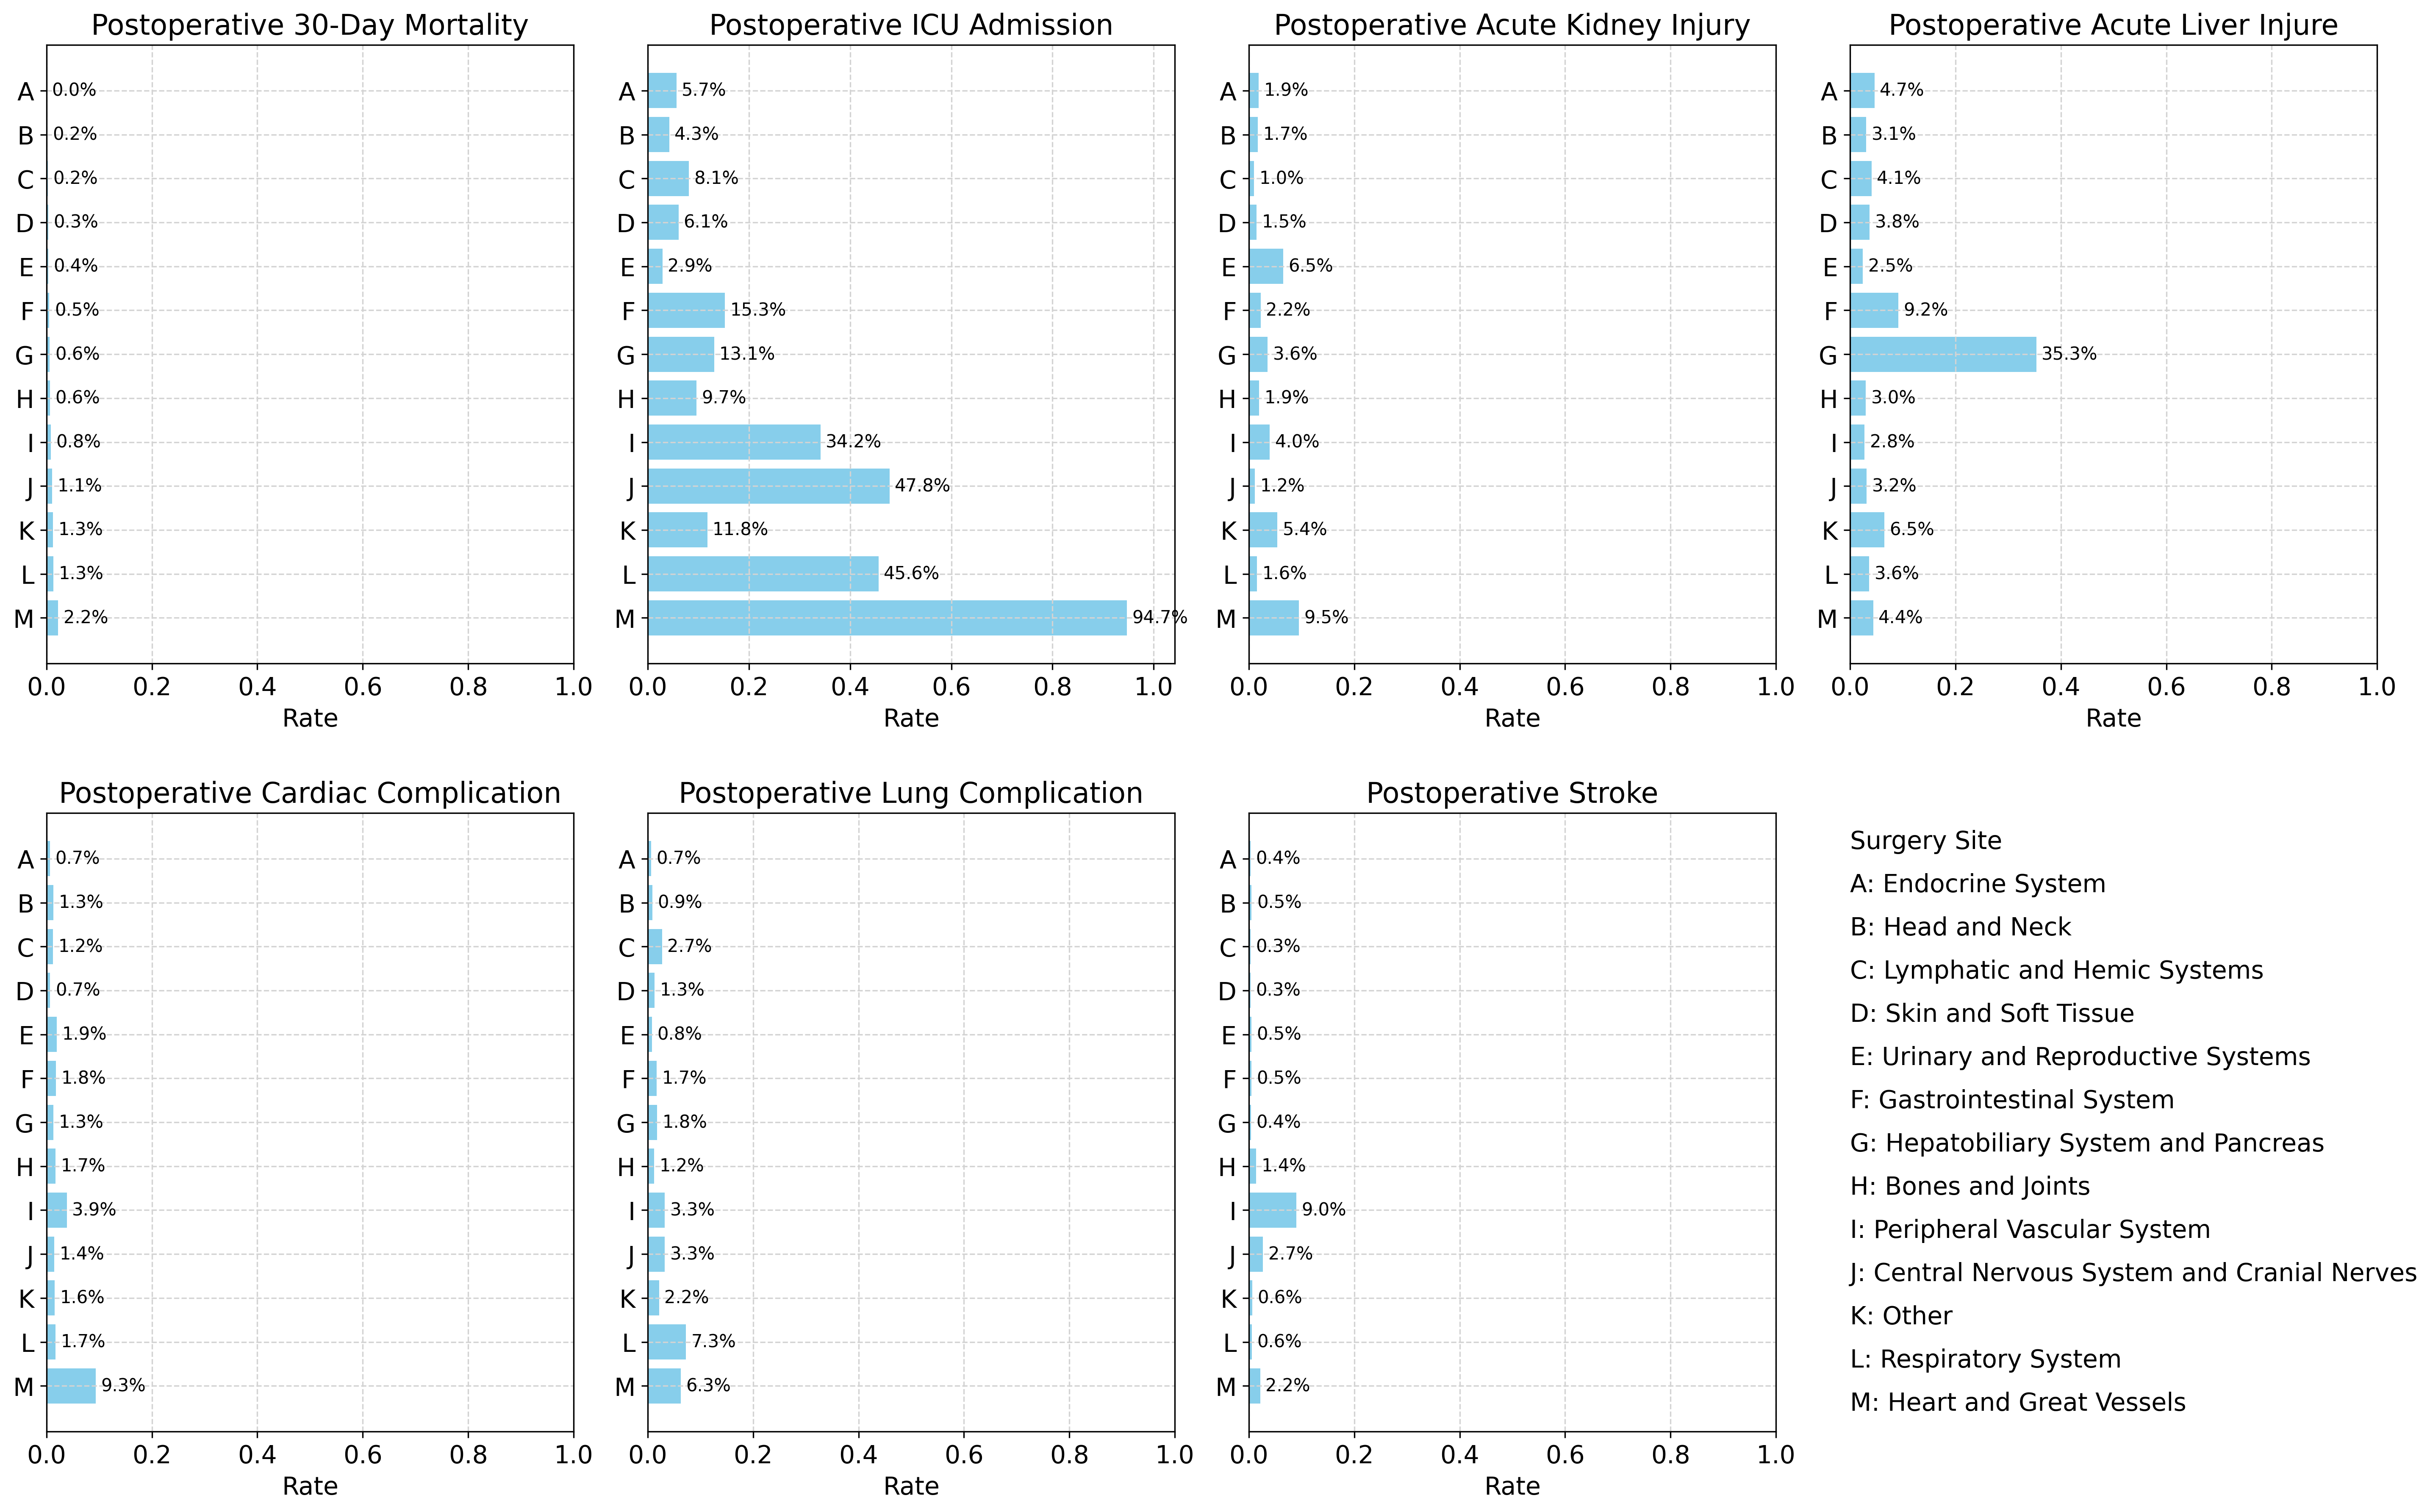

In [11]:
# 定义系统名称与字母标签的映射
system_labels = {
    'Endocrine_System': 'A',
    'Head_and_Neck': 'B',
    'Lymphatic_and_Hemic_Systems': 'C',
    'Skin_and_Soft_Tissue': 'D',
    'Urinary_and_Reproductive_Systems': 'E',
    'Gastrointestinal_System': 'F',
    'Hepatobiliary_System_and_Pancreas': 'G',
    'Bones_and_Joints': 'H',
    'Peripheral_Vascular_System': 'I',
    'Central_Nervous_System_and_Cranial_Nerves': 'J',
    'Other': 'K',
    'Respiratory_System': 'L',
    'Heart_and_Great_Vessels': 'M'
}

# 创建图表
fig, axes = plt.subplots(2, 4, figsize=(20, 12), dpi=300)
plt.subplots_adjust(hspace=0.5)

# Flatten the axes array for easy indexing
axes = axes.flatten()

# Columns to plot
columns_to_plot = ['Postoperative 30-Day Mortality Rate', 'Postoperative ICU Admission Rate', 
                   'Postoperative AKI Incidence Rate', 'Postoperative ALI Incidence Rate', 
                   'Postoperative Cardiac Complication Rate', 'Postoperative Lung Complication Rate', 
                   "Postoperative Stroke Rate"]

columns_name = ['Postoperative 30-Day Mortality', 'Postoperative ICU Admission', 
                'Postoperative Acute Kidney Injury', 'Postoperative Acute Liver Injure', 
                'Postoperative Cardiac Complication', 'Postoperative Lung Complication', 
                "Postoperative Stroke"]

# 准备一个简化版本的系统名称字典，用于匹配
simplified_system_labels = {}
for system, letter in system_labels.items():
    # 将系统名称简化为小写并去除下划线，便于匹配
    simple_key = system.lower().replace('_', '').replace(' ', '')
    simplified_system_labels[simple_key] = letter

# Plot each rate as a horizontal bar chart
for i, (col, col_name) in enumerate(zip(columns_to_plot, columns_name)):
    # Handle possible NaN values
    plot_data = rates.copy()
    plot_data[col] = plot_data[col].fillna(0)
    
    # Plot horizontal bar chart
    bars = axes[i].barh(plot_data['Surgery Site'], plot_data[col], color='skyblue')
    axes[i].set_title(f'{col_name}', fontname='DejaVu Sans', fontsize=16)  # 放大标题字体
    axes[i].set_xlabel('Rate', fontname='DejaVu Sans', fontsize=14)  # 放大x轴标签字体
    
    # Set ylabel font size
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].tick_params(axis='x', labelsize=14)  # 放大x轴标签字体
    
    # Add percentage labels to the right of the bars
    for bar in bars:
        width = bar.get_width()
        label_x_pos = width + 0.01
        axes[i].text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.1%}',
                    va='center', fontname='DejaVu Sans')
    
    # Set x-axis limits to keep all charts consistent
    axes[i].set_xlim(0, max(1.0, plot_data[col].max() * 1.1))
    
    # 添加浅灰色网格线
    axes[i].grid(True, linestyle='--', color='lightgrey')
    
    # 直接替换 y 轴标签为字母
    new_labels = []
    for category in plot_data['Surgery Site']:
        # 将类别名称简化，以便与系统标签匹配
        simple_cat = category.lower().replace(' ', '').replace('_', '')
        
        # 尝试找到匹配的标签
        letter_found = False
        for system_key, letter in system_labels.items():
            simple_system = system_key.lower().replace('_', '').replace(' ', '')
            if simple_system in simple_cat or simple_cat in simple_system:
                new_labels.append(letter)
                letter_found = True
                break
                
        # 如果找不到匹配项，保留原标签
        if not letter_found:
            new_labels.append(category)
    
    # 设置新的 y 轴标签
    axes[i].set_yticks(range(len(new_labels)))
    axes[i].set_yticklabels(new_labels)

# Hide any unused subplots
for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

# 在第2行第4列添加图例
legend_ax = axes[7]  # 数组中的第8个元素，对应2行4列
legend_ax.clear()
legend_ax.axis('off')

# 添加图例文本
legend_text = "\n".join([f"{letter}: {system.replace('_', ' ')}" 
                        for system, letter in system_labels.items()])
legend_text = "Surgery Site\n" + legend_text  # 添加一行字 "Surgery Site"
legend_ax.text(0, 0.5, legend_text, fontsize=14, fontname='DejaVu Sans',
              verticalalignment='center', horizontalalignment='left',
              linespacing=2)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np

def create_focused_summary_table(df):
    # 创建一个包含原始数据和overall数据的副本
    df_with_overall = df.copy()
    # 添加"overall"作为额外的dataset值
    df_with_overall.loc[:, 'dataset'] = 'overall'
    # 合并原始数据和overall数据
    combined_df = pd.concat([df, df_with_overall])
    
    # 按dataset分组，确保overall排在最前面
    unique_datasets = sorted(df['dataset'].unique())
    all_indices = ['overall'] + unique_datasets
    result = pd.DataFrame(index=all_indices)
    result.index.name = 'dataset'
    
    # 样本量
    sample_counts = combined_df.groupby('dataset').size()
    result['样本量'] = sample_counts
    
    # 统计唯一标识符数量
    result['唯一op_id数'] = combined_df.groupby('dataset')['op_id'].nunique()
    result['唯一subject_id数'] = combined_df.groupby('dataset')['subject_id'].nunique()
    
    # 连续型变量列表：持续时间和人口统计学变量
    continuous_vars = [
        'age', 'weight', 'height', 'bmi', 
        'op_duration', 'or_duration', 'an_duration', 
        'cpb_duration', 'icu_duration', 'los',
        'CCI_score', 'RCRI_score', 'sort_score'
    ]
    
    # 统计连续型变量
    for col in continuous_vars:
        if col in combined_df.columns:
            for dataset_id in result.index:
                group_data = combined_df[combined_df['dataset'] == dataset_id][col]
                if len(group_data) > 0 and not group_data.isnull().all():
                    mean_val = group_data.mean()
                    std_val = group_data.std()
                    result.loc[dataset_id, col] = f"{mean_val:.2f}±{std_val:.2f}"
                else:
                    result.loc[dataset_id, col] = "N/A"
    
    # 需要特殊处理的多类别变量列表
    multi_category_vars = ['surgery_site', 'race', 'asa']  # 将asa添加为多类别变量
    
    # 二元分类变量列表
    binary_vars = ['sex', 'emop']
    
    # 特殊处理多类别变量：为每个类别创建单独的列
    for col in multi_category_vars:
        if col in combined_df.columns:
            # 获取该变量的所有唯一值
            all_categories = sorted(combined_df[col].dropna().unique())
            
            for dataset_id in result.index:
                group_data = combined_df[combined_df['dataset'] == dataset_id]
                total = len(group_data)
                
                if total == 0:
                    continue
                
                # 计算该列非缺失值的总数
                valid_count = group_data[col].count()
                
                # 为每个类别创建单独的列，显示频数和百分比
                for category in all_categories:
                    count = (group_data[col] == category).sum()
                    pct = count / valid_count * 100 if valid_count > 0 else 0
                    col_name = f"{col}_{category}"
                    result.loc[dataset_id, col_name] = f"{count} ({pct:.1f}%)"
    
    # 统计二元分类变量
    for col in binary_vars:
        if col in combined_df.columns:
            for dataset_id in result.index:
                group_data = combined_df[combined_df['dataset'] == dataset_id]
                valid_data = group_data[col].dropna()
                
                if len(valid_data) == 0:
                    result.loc[dataset_id, col] = "N/A"
                    continue
                
                # 计算1的频数和百分比
                count = (valid_data == 1).sum()
                pct = count / len(valid_data) * 100
                result.loc[dataset_id, col] = f"{count} ({pct:.1f}%)"
    
    # 术后并发症列表
    postop_vars = [
        'have_icu', 'have_aki', 'have_ali', 
        'postop_cardiac_complications', 'postop_lung_complications',
        'death_30d','postop_stroke'
    ]
    
    # 统计术后并发症
    for col in postop_vars:
        if col in combined_df.columns:
            for dataset_id in result.index:
                group_data = combined_df[combined_df['dataset'] == dataset_id][col]
                valid_data = group_data.dropna()
                
                if len(valid_data) == 0:
                    result.loc[dataset_id, col] = "N/A"
                    continue
                
                # 计算发生率(1的比例)
                count = (valid_data == 1).sum()
                pct = count / len(valid_data) * 100
                result.loc[dataset_id, col] = f"{count} ({pct:.1f}%)"
    
    # 统计所有术前合并症(preop_开头的列)
    preop_cols = [col for col in combined_df.columns if col.startswith('preop_')]
    
    for col in preop_cols:
        for dataset_id in result.index:
            group_data = combined_df[combined_df['dataset'] == dataset_id][col]
            valid_data = group_data.dropna()
            
            if len(valid_data) == 0:
                result.loc[dataset_id, col] = "N/A"
                continue
            
            # 计算发生率(1的比例)
            count = (valid_data == 1).sum()
            pct = count / len(valid_data) * 100
            result.loc[dataset_id, col] = f"{count} ({pct:.1f}%)"
    
    return result

# 生成统计表格
summary_table = create_focused_summary_table(df)

# 显示表格
print(summary_table)


            样本量  唯一op_id数  唯一subject_id数          age       weight  \
dataset                                                              
overall  101367    101367          82137  54.64±15.69  62.08±11.22   
1         71001     71001          57495  54.59±15.72  62.08±11.25   
2         20259     20259          16427  54.78±15.61  62.08±11.17   
3         10107     10107           8215  54.74±15.69  62.11±11.17   

              height         bmi    op_duration    or_duration    an_duration  \
dataset                                                                         
overall  161.84±8.54  23.64±3.47  134.58±111.28  187.29±133.49  171.87±121.16   
1        161.84±8.54  23.64±3.47  134.75±111.60  187.43±135.28  172.07±121.60   
2        161.79±8.55  23.66±3.48  134.74±111.05  187.78±132.22  171.93±120.18   
3        161.95±8.50  23.62±3.44  133.12±109.47  185.36±123.03  170.34±120.09   

         ... preop_neoplasms_of_uncertain_behavior  \
dataset  ...                          

In [63]:
# 保存完整结果
summary_table.T.to_csv('dataset_summary1.csv', encoding='gbk')